## 피처 생성 (Feature Creation)

#### 기존 데이터를 변형·결합하여 모델 성능을 향상시킬 수 있는 **새로운 특성(피처)을 만들어내는** 전처리 과정.
> 원본 데이터만으로는 드러나지 않는 패턴이나 관계를 새로운 피처로 표현하면, 모델이 더 풍부한 정보를 학습할 수 있다.

#### 왜 피처 생성이 중요한가?
- **표현력 확장**: 원본 피처의 조합·변형을 통해 데이터에 숨겨진 패턴을 명시적으로 드러낸다.
- **모델 성능 향상**: 적절한 파생 변수는 복잡한 모델 없이도 예측 정확도를 크게 높일 수 있다.
- **도메인 지식 반영**: 비즈니스·도메인 관점에서 의미 있는 피처를 직접 설계할 수 있다.

#### 주요 피처 생성 기법
| 기법 | 설명 | 예시 |
|---|---|---|
| **날짜 분해** | datetime에서 연·월·일·시·요일 등 구성 요소 추출 | `datetime` → `year`, `month`, `hour`, `weekday` |
| **조건 결합** | 여러 피처의 조건을 결합하여 새로운 범주 생성 | `holiday` + `workingday` → `worktype` |
| **집계 통계** | groupby 기반 평균·합계 등 통계량을 파생 피처로 추가 | 시간대별 평균 대여량 → `mean_count_by_hour` |
| **산술 연산** | 기존 피처 간 사칙연산으로 새로운 관계 표현 | `피처A / 피처B`, `피처A × 피처B` |
| **구간화 (Binning)** | 연속형 값을 범주형 구간으로 변환 | 기온 → 저온·중온·고온 |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# plt.rcParams['font.family'] = 'AppleGothic'

In [2]:
df = pd.read_csv('./dataset/featurecreation.csv')

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


#### 날짜 데이터로부터 피쳐 생성

In [3]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%Y-%m-%d %H:%M:%S')

df.dtypes

datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object

In [4]:
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

df.drop('datetime', axis=1, inplace=True)

df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5


#### 주중/주말별 자전거 대여량

In [5]:
df['workingday'].value_counts()

workingday
1    7412
0    3474
Name: count, dtype: int64

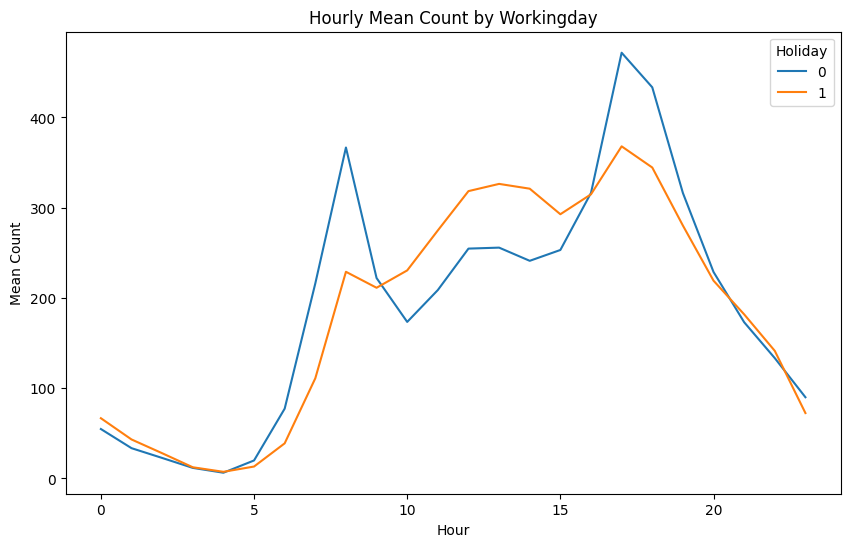

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='hour', y='count', hue='holiday', errorbar=None)
plt.title('Hourly Mean Count by Workingday')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='Holiday')
plt.show()

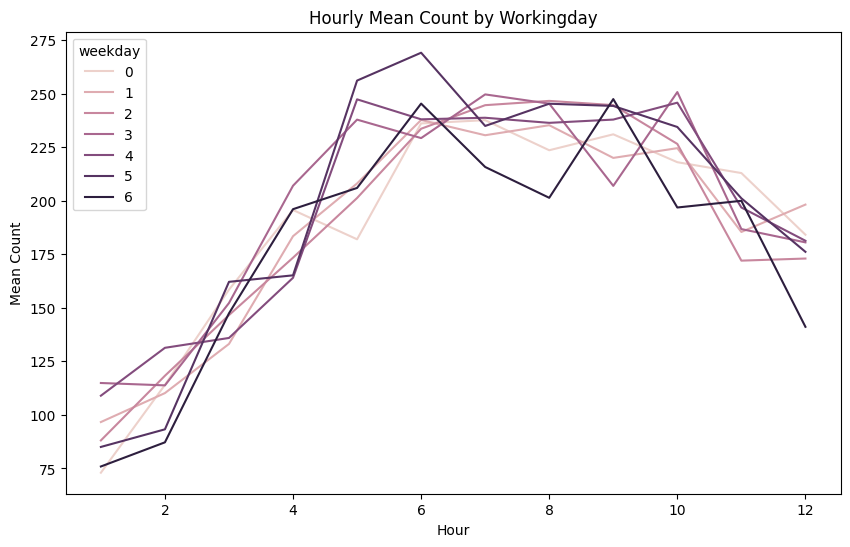

In [ ]:
## working day -> 0~4 (월~금)
## no working day -> 5,6 (토,일)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='month', y='count', hue='weekday', errorbar = None)
plt.title('Hourly Mean Count by Workingday')
plt.xlabel('Hour')
plt.ylabel('Mean Count')
plt.legend(title='weekday')
plt.show()

#### 평균값 파생 피쳐 추가

In [ ]:
# 시간별 평균 대여량 파생 피처 추가

groupby_df = df.groupby('hour')['count'].mean().reset_index()
groupby_df.columns = ['hour', 'mean_count_by_hour']

groupby_df

,hour,mean_count_by_hour
0,0,55.138462
1,1,33.859031
2,2,22.899554
3,3,11.757506
4,4,6.407240
5,5,19.767699
6,6,76.259341
7,7,213.116484
8,8,362.769231
9,9,221.780220


In [30]:
df = df.merge(groupby_df, on='hour', how='left')

df.head()


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,weekday,worktype,mean_count_by_hour
0,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5,1,55.138462
1,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5,1,33.859031
2,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5,1,22.899554
3,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5,1,11.757506
4,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5,1,6.407240
